# Forecast demo
Here we load the trained Aardvark Weather model and produce a global and station forecast using the sample data. 

In [5]:
import io
import sys
sys.path.append("../aardvark")

import pickle
import numpy as np
from e2e_model import *

import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

Check a GPU is available

In [6]:
import torch

if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Using Apple MPS (Metal) GPU.")
else:
    device = "cpu"
    print("No GPU found, using CPU.")

Using Apple MPS (Metal) GPU.


## Generate predictions

Load the sample data (for a detailed analysis and visualisation of the contents of this dataset see data_demo.ipynb)

In [7]:
class CPU_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

def move_to_device(obj, device):
    if isinstance(obj, torch.Tensor):
        return obj.to(device)
    elif isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]
    elif isinstance(obj, tuple):
        return tuple(move_to_device(v, device) for v in obj)
    return obj

with open("../data/sample_data_final.pkl", "rb") as fp:
    data = CPU_Unpickler(fp).load()

data = move_to_device(data, device)

Load the model to generate predictions at one day leadtime. First select which varaible to generate station forecasts for.

In [8]:
local_forecast_var = "tas"  # Model weights included for windspeed (ws) and 2tm (tas)

model = ConvCNPWeatherE2E(
    device=device,
    lead_time=1,
    se_model_path="../trained_models/encoder",
    forecast_model_path="../trained_models/processor",
    sf_model_path=f"../trained_models/decoder/{local_forecast_var}/",
    return_gridded=True,
    aux_data_path="../data/",
)

Run the model to generate a forecast the sample data. This outputs the station forecast, gridded forevast and initial state

In [9]:
station_forecast, global_forecast, initial_state = model(data)

## Visualise model predictions

First look at the gridded forecasts. Visualise several variables

In [10]:
vars = [
    "u10",
    "v10",
    "t2m",
    "mslp",
    "z200",
    "z500",
    "z700",
    "z850",
    "q200",
    "q500",
    "q700",
    "q850",
    "t200",
    "t500",
    "t700",
    "t850",
    "u200",
    "u500",
    "u700",
    "u850",
    "v200",
    "v500",
    "v700",
    "v850",
]

var_index_mapping = {k: v for v, k in enumerate(vars)}

In [11]:
lon = np.linspace(0, 359, 240)
lat = np.linspace(-90, 90, 121)

Select the variable and data to plot. To plot another variable simply change the variable argument below. 

In [12]:
variable = "u10"
var_index = var_index_mapping[variable]
initial_state_var = initial_state[0, ..., var_index].detach().cpu().numpy()
global_forecast_var = global_forecast[0, ..., var_index].detach().cpu().numpy()
colorscale_mag = np.max(np.abs(initial_state_var))

Plot the initial state

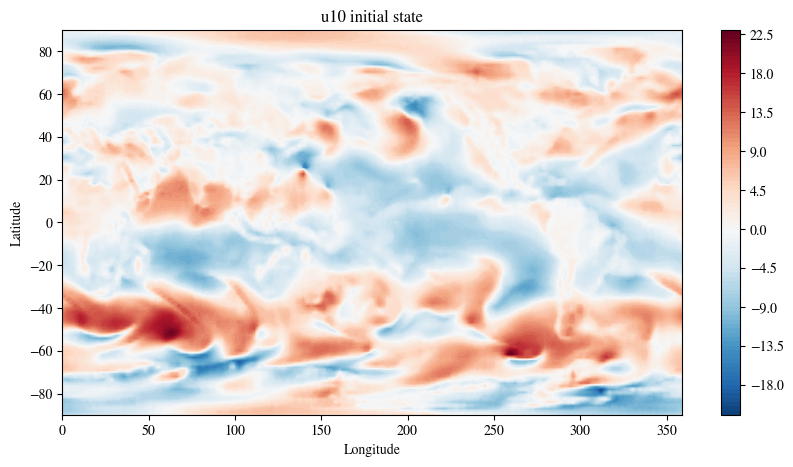

In [13]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    initial_state_var,
    levels=100,
    vmax=colorscale_mag,
    vmin=-colorscale_mag,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
# cbar.set_label('(m/s)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{variable} initial state")
plt.show()

Plot the prediction at one day leadtime

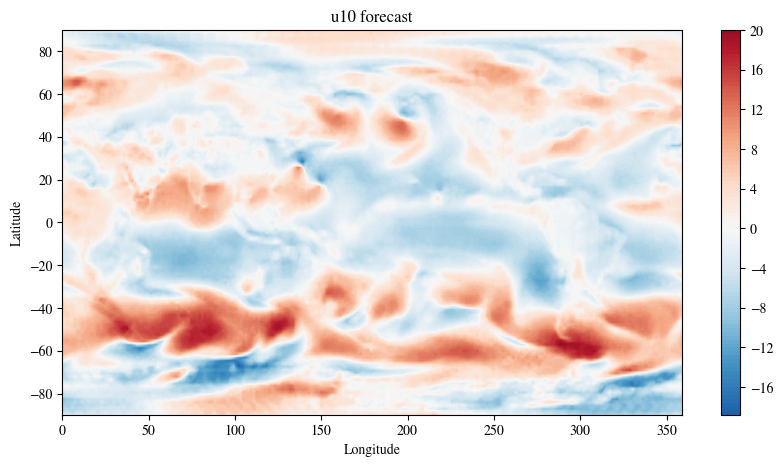

In [14]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.contourf(
    lon,
    lat,
    global_forecast_var,
    levels=100,
    vmax=colorscale_mag,
    vmin=-colorscale_mag,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
# cbar.set_label('(m/s)')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{variable} forecast")
plt.show()

The model also returns the station forecasts for T2M

In [15]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10
# Factors to unnormalise predictions
mean = np.load(f"../data/norm_factors/mean_hadisd_{local_forecast_var}.npy")
std = np.load(f"../data/norm_factors/std_hadisd_{local_forecast_var}.npy")

In [16]:
station_forecast = (
    station_forecast.detach().cpu() * std + mean
) * HADISD_SCALING_FACTOR

/var/folders/px/747r5b694x947qk1vdh9b3th0000gp/T/ipykernel_25057/3168040627.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  station_forecast.detach().cpu() * std + mean


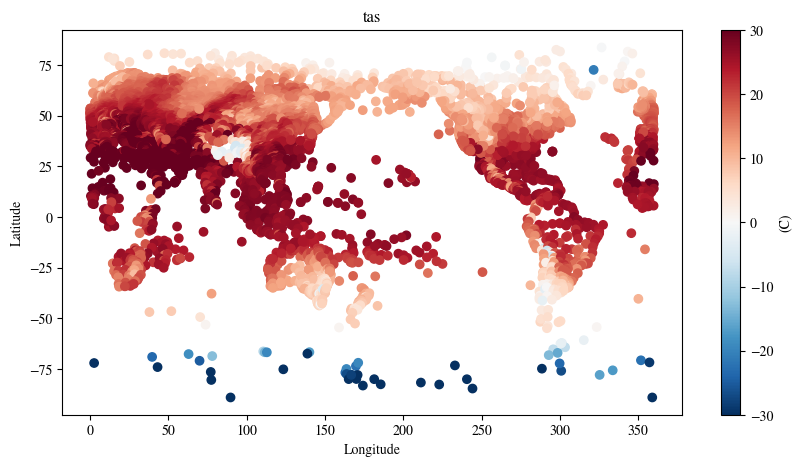

In [17]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.scatter(
    data["downscaling"]["x_target"][0, 0, :].detach().cpu() * STATION_LON_LAT_SF,
    data["downscaling"]["x_target"][0, 1, :].detach().cpu() * STATION_LON_LAT_SF,
    c=station_forecast[0, :],
    vmax=30,
    vmin=-30,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
cbar.set_label("(C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{local_forecast_var}")
plt.show()